In [2]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

jit_find_library(): Unable to load "/usr/lib/llvm-15/lib/libLLVM.so": /home/jonathan/miniconda3/envs/volprim/lib/python3.11/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/llvm-15/lib/libLLVM.so)!


/tmp/ipykernel_3316288/4103183378.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


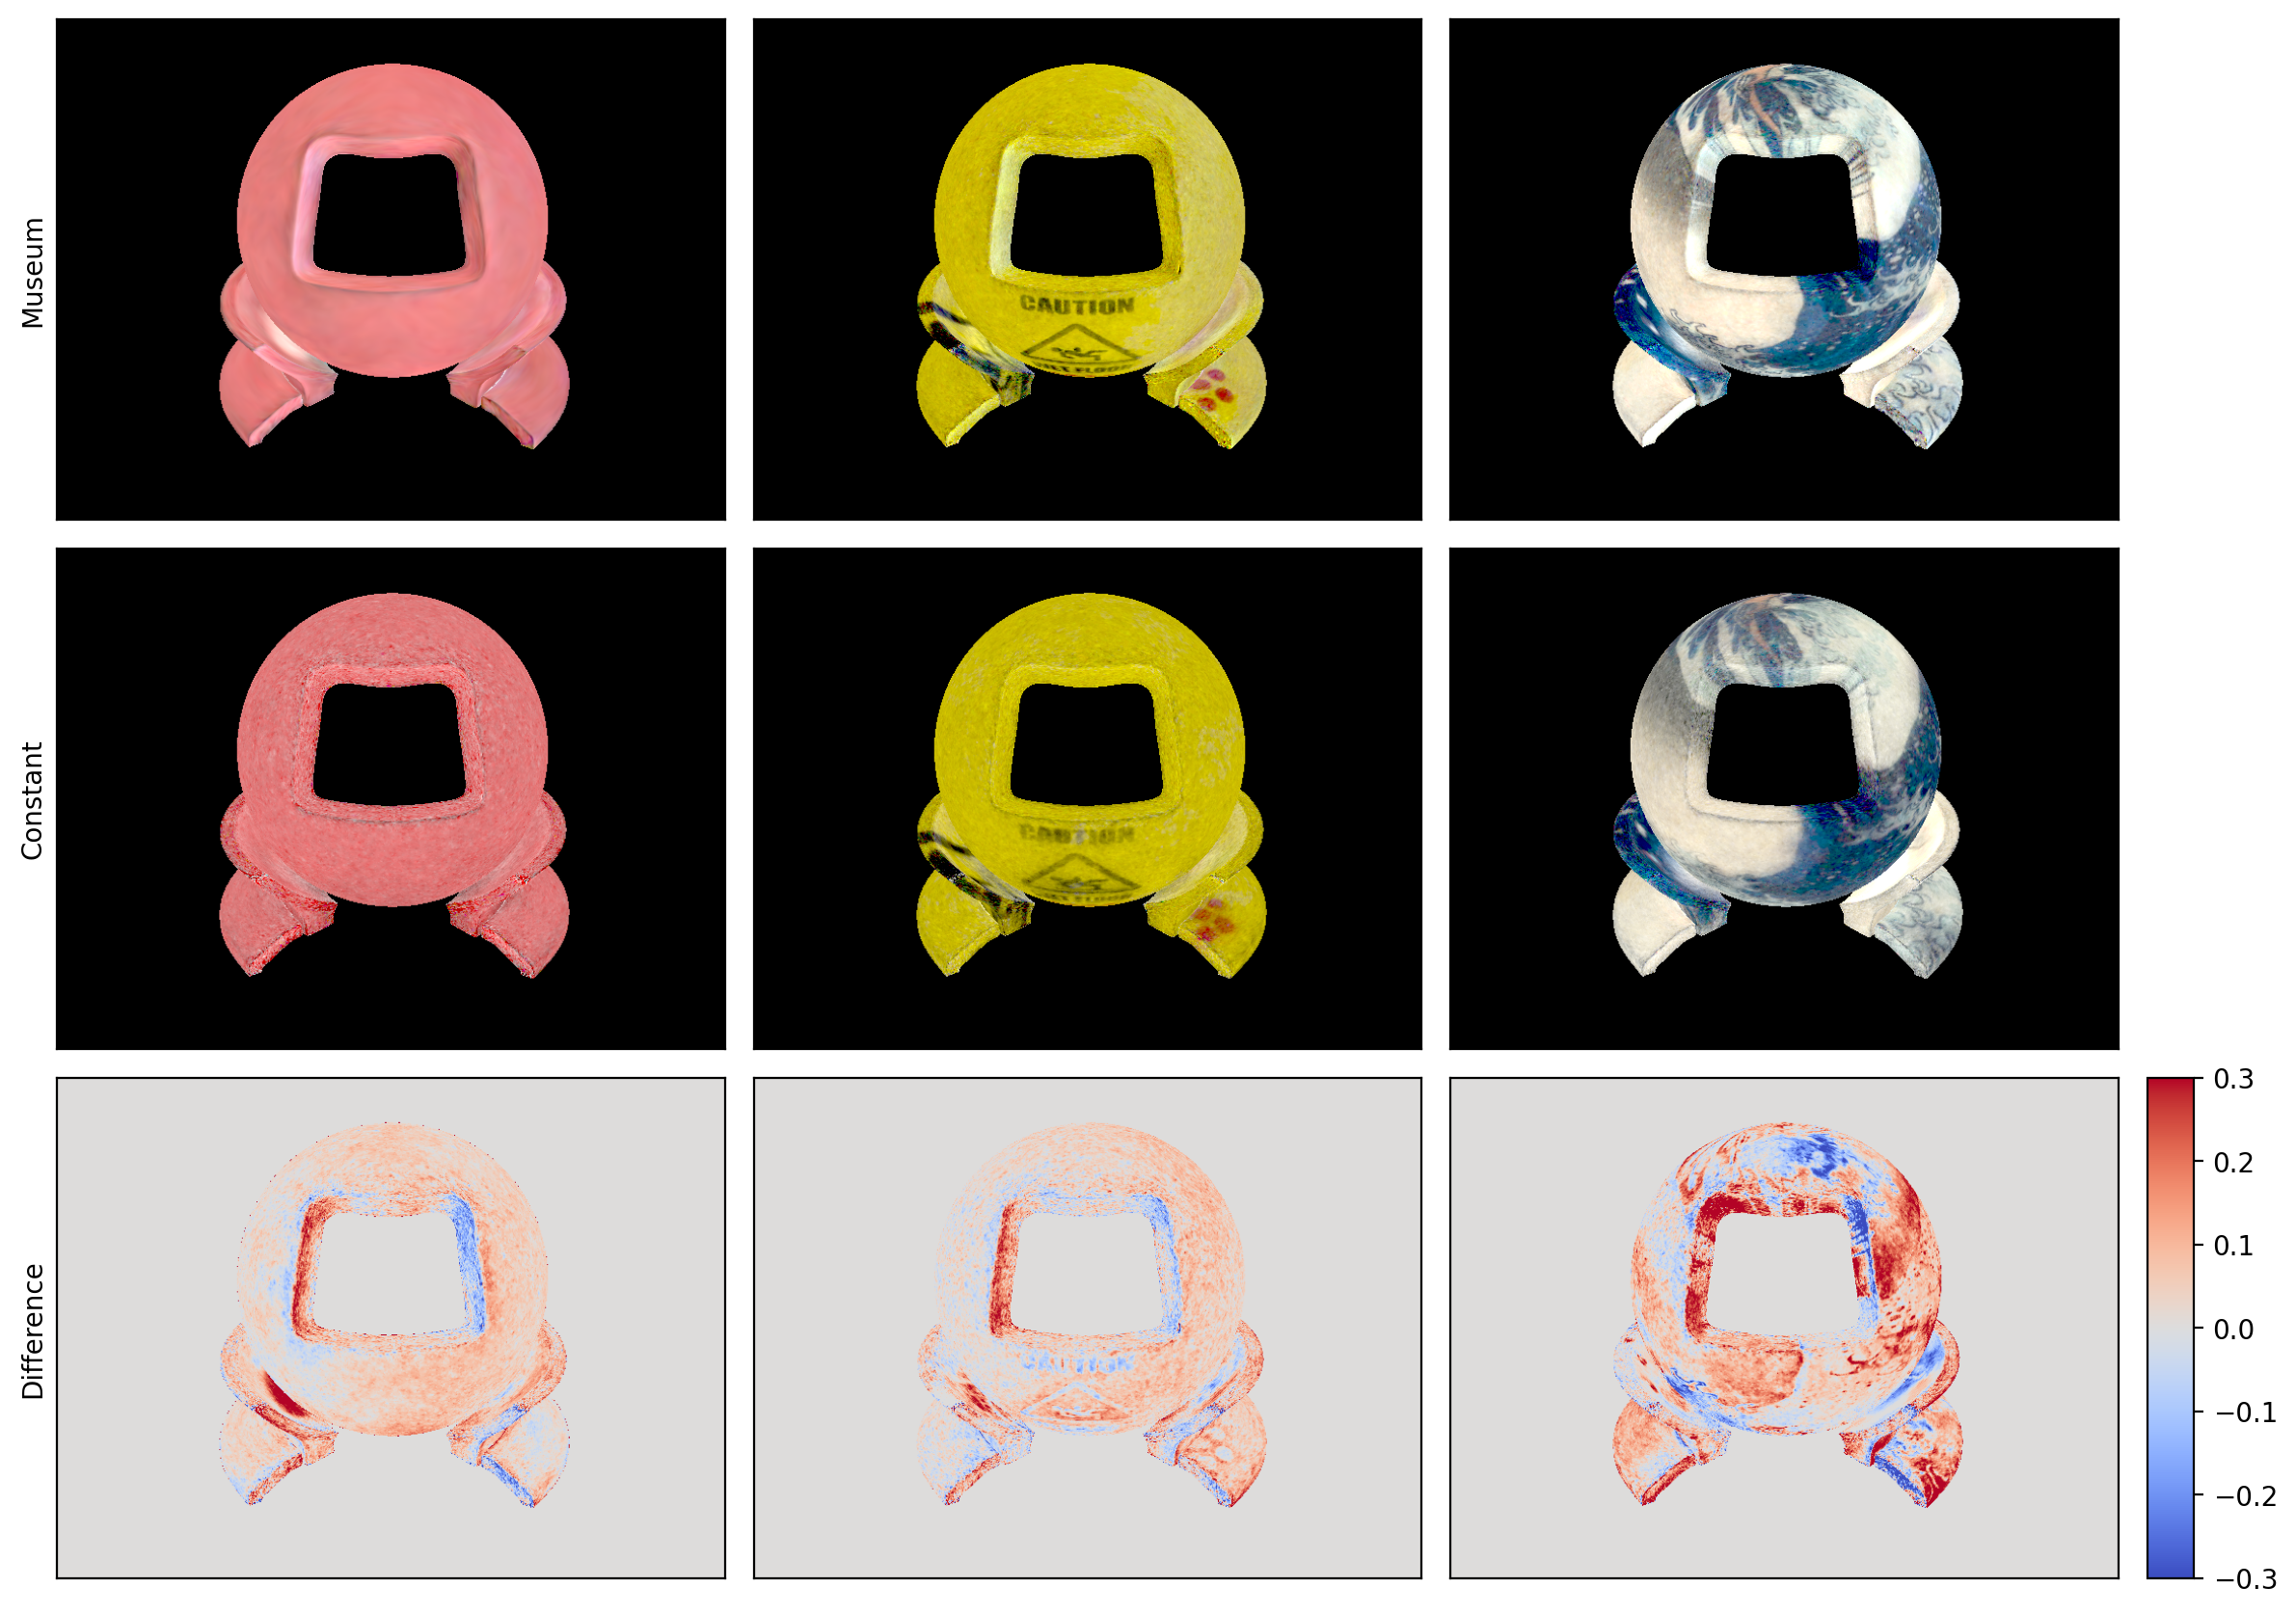

In [3]:
import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

fp = "/home/jonathan/Documents/volprim-balance/exp23/"
scenes = ["red", "floor", "wave"]
envs = ["constant", "museum"]

num_scenes = len(scenes)
num_envs = len(envs)
ylabels = ["Museum", "Constant", "Difference"]

# Set up figure and image grid
scale = 4
fig = plt.figure(figsize=(num_scenes * scale, 2.2 * scale), dpi=200)
grid = ImageGrid(fig, 111,
                 nrows_ncols=(3,3),
                 axes_pad=0.15,
                 share_all=True,
                 cbar_location="right",
                 cbar_mode="edge",
                 cbar_size="7%",
                 cbar_pad=0.15,
                 )


for col, scene in enumerate(scenes):
    img_const  = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}-constant.exr")).split()[1][1])
    img_museum = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}-museum.exr")  ).split()[1][1])

    error = img_museum - img_const
    error = (error[:,:,0] + error[:,:,1] + error[:,:,2]) / 3.0

    error_range = dr.max(dr.abs(error), axis=None).numpy().item()
    error_range = 0.3

    # GS image
    ax = grid[0 + col]
    ax.imshow(img_museum ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(ylabels[0])

    # RT image
    ax = grid[3 + col]
    ax.imshow(img_const ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(ylabels[1])

    # Error image
    ax = grid[6 + col]
    im = ax.imshow(error, vmin=-error_range, vmax=error_range, cmap='coolwarm'); ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel(ylabels[2])

# Colorbar
ax.cax.colorbar(im)

grid.cbar_axes[0].remove()
grid.cbar_axes[1].remove()

plt.tight_layout()
plt.savefig("Exp2-3_albedo.png")